In [109]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [28]:
# read data
import csv
import pandas as pd

csv_filename = 'game_events_2026-02-25T16:39:43.024297.csv'

data = []

with open(csv_filename, 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    for raw_row in reader:
        row = {
            'hostingPlatform': raw_row['hostingPlatform'],
            'gameVersion': raw_row['gameVersion'],
            'sessionId': raw_row['sessionId'],
            'eventType': raw_row['eventType'],
            'subversion': raw_row['subversion'],
            'sceneName': raw_row['sceneName'],
            'description': raw_row['description'],
            'index': int(raw_row['index']),
            'timestamp': pd.to_datetime(raw_row['timestamp']),
            'elapsedTime': float(raw_row['elapsedTime']),
            'gameState_helpedToday': int(raw_row['gameState_helpedToday']),
            'gameState_totalFlagged': int(raw_row['gameState_totalFlagged']),
            'gameState_correctToday': int(raw_row['gameState_correctToday']),
            'gameState_flaggedToday': int(raw_row['gameState_flaggedToday']),
            'gameState_totalReported': int(raw_row['gameState_totalReported']),
            'gameState_totalHelped': int(raw_row['gameState_totalHelped']),
            'gameState_reportedToday': int(raw_row['gameState_reportedToday']),
            'gameState_totalCorrect': int(raw_row['gameState_totalCorrect'])
        }
        data.append(row)

In [50]:
df = pd.DataFrame(data)
df.head()

,hostingPlatform,gameVersion,sessionId,eventType,subversion,sceneName,description,index,timestamp,elapsedTime,gameState_helpedToday,gameState_totalFlagged,gameState_correctToday,gameState_flaggedToday,gameState_totalReported,gameState_totalHelped,gameState_reportedToday,gameState_totalCorrect
0,itch,0.1,bddfeebe-f6c8-4836-a7ca-edecf330bae0,item_clicked,A,Scene1_Day1_V2,4_SExamGuide (I),0,2026-02-22 23:49:26.856000+00:00,0.0,0,0,3,0,0,0,0,3
1,itch,0.1,4f717f94-1607-4cbd-83e6-b33049a1d003,item_clicked,A,Scene1_Day1_V2,1_SExamGuide (I),0,2026-02-23 06:40:56.569000+00:00,0.0,0,0,0,0,0,0,0,0
2,itch,0.1,550d6cf8-508e-4c39-ad95-fbeb47770794,item_clicked,A,Scene1_Day1_V2,2_SReviewFolder (I),0,2026-02-22 21:09:28.277000+00:00,0.0,0,0,1,0,0,0,0,1
3,itch,0.1,2c6da7fd-cac4-4343-b1d6-1c629f174b61,item_clicked,A,Scene1_Day1_V2,1_SStudentID (I),0,2026-02-25 06:59:47.026000+00:00,0.0,0,0,0,0,0,0,0,0
4,itch,0.1,f4705d45-e1e9-4cbc-8490-58c59554e625,credits_page_entered,A,Scene0_Title,,0,2026-02-23 05:33:22.495000+00:00,0.0,1,0,4,0,0,1,0,4


In [51]:
# number of unique sessions
num_sessions = df['sessionId'].nunique()
print(f'Number of unique sessions: {num_sessions}')

Number of unique sessions: 99


In [161]:
def analyze_playtime(dataframe, name):
    playtime = dataframe.groupby('sessionId')['timestamp'].agg(['min', 'max'])
    playtime['playtime'] = (playtime['max'] - playtime['min']).dt.total_seconds() / 60  # convert to minutes
    playtime.sort_values('playtime', ascending=False, inplace=True)
    print(f'Playtime statistic for {name}:\n{playtime["playtime"].describe()}')

    # retention graph
    print('Retention graph:')
    time_bins = np.arange(0, 31, 1)
    retention = [100 * (playtime['playtime'] >= t).mean() for t in time_bins[:30]]
    plt.stairs(retention, time_bins, fill=True)
    plt.xlabel('Playtime (minutes)')
    plt.ylabel('Retention (%)')
    plt.title(f'Retention by playtime for {name}')

    # chronological game events graph
    plt.figure()

def analyze_retention_by_milestone(dataframe, name):
    game_stage_names = ['start', 'scene1', 'orientation', 'decision1', 'decision2', 'decision3', 'decision4', 'decision5', 'scene2', 'scene3', 'supervisor talk', 'eval signed']
    sessions_by_stage = []
    # start with all sessions, and keep pruning down to those that reached each stage

    # start
    current_sessions = dataframe
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # scene1
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'scene_entered') & (current_sessions['sceneName'] == 'Scene1_Day1_V2')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # orientation
    # currently don't have a great way to identify this,
    # use item_clicked with description = "1_SReviewFolder (I)" as a proxy for now
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'item_clicked') & (current_sessions['description'] == '1_SReviewFolder (I)')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # decision 1: identify by either 
    # event_type = "admission_decision_correct" and description = "Admitted student Student1 (I)"
    # OR event_type = "admission_decision_incorrect" and description = "Denied student Student1 (I)"
    filtered_ids = current_sessions[
        ((current_sessions['eventType'] == 'admission_decision_correct') & (current_sessions['description'] == 'Admitted student Student1 (I)')) |
        ((current_sessions['eventType'] == 'admission_decision_incorrect') & (current_sessions['description'] == 'Denied student Student1 (I)'))
    ]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # decision 2: identify by either 
    # event_type = "admission_decision_correct" and description = "Admitted student Student2 (I)"
    # OR event_type = "admission_decision_incorrect" and description = "Denied student Student2 (I)"
    filtered_ids = current_sessions[
        ((current_sessions['eventType'] == 'admission_decision_correct') & (current_sessions['description'] == 'Admitted student Student2 (I)')) |
        ((current_sessions['eventType'] == 'admission_decision_incorrect') & (current_sessions['description'] == 'Denied student Student2 (I)'))
    ]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # decision 3: identify by either 
    # event_type = "admission_decision_correct" and description = "Admitted student Student3 (I)"
    # OR event_type = "admission_decision_incorrect" and description = "Denied student Student3 (I)"
    filtered_ids = current_sessions[
        ((current_sessions['eventType'] == 'admission_decision_correct') & (current_sessions['description'] == 'Admitted student Student3 (I)')) |
        ((current_sessions['eventType'] == 'admission_decision_incorrect') & (current_sessions['description'] == 'Denied student Student3 (I)'))
    ]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # decision 4: identify by either 
    # event_type = "admission_decision_correct" and description = "Admitted student Student4 (I)"
    # OR event_type = "admission_decision_incorrect" and description = "Denied student Student4 (I)"
    filtered_ids = current_sessions[
        ((current_sessions['eventType'] == 'admission_decision_correct') & (current_sessions['description'] == 'Admitted student Student4 (I)')) |
        ((current_sessions['eventType'] == 'admission_decision_incorrect') & (current_sessions['description'] == 'Denied student Student4 (I)'))
    ]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # decision 5 (bad student): identify by either 
    # event_type = "admission_decision_correct" and description = "Denied student Student5 (I)"
    # OR event_type = "admission_decision_incorrect" and description = "Admitted student Student5 (I)"
    filtered_ids = current_sessions[
        ((current_sessions['eventType'] == 'admission_decision_correct') & (current_sessions['description'] == 'Denied student Student5 (I)')) |
        ((current_sessions['eventType'] == 'admission_decision_incorrect') & (current_sessions['description'] == 'Admitted student Student5 (I)'))
    ]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # scene 2: identify by scene_entered with sceneName = "Scene2_Day1_V2"
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'scene_entered') & (current_sessions['sceneName'] == 'Scene2_Day1_V2')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]   
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # scene 3: identify by scene_entered with sceneName = "Scene3_Day1_V2"
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'scene_entered') & (current_sessions['sceneName'] == 'Scene3_Day1_V2')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # supervisor talk: identify by eventType = "supervisor_talk_clicked"
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'supervisor_talk_clicked')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # eval signed: identify by eventType = "eval_signed"
    filtered_ids = current_sessions[(current_sessions['eventType'] == 'eval_signed')]['sessionId']
    current_sessions = current_sessions[current_sessions['sessionId'].isin(filtered_ids)]
    sessions_by_stage.append(current_sessions['sessionId'].nunique())

    # plot as histogram, with labels being the stage names
    milestone_retention_percentages = [100 * count / sessions_by_stage[0] for count in sessions_by_stage]
    plt.bar(game_stage_names, milestone_retention_percentages, color='chocolate')
    plt.xticks(rotation=-90)
    plt.xlabel('Game Milestone')
    plt.ylabel('Retention (%)')
    plt.title(f'Retention by game milestone for {name}')

def analyze(dataframe, name):
    analyze_playtime(dataframe, name)
    analyze_retention_by_milestone(dataframe, name)

In [97]:
# filter out sessions that did not enter scene 1
played_session_ids = df[(df['eventType'] == 'scene_entered') & (df['sceneName'] == 'Scene1_Day1_V2')]['sessionId']

# join back with main df
played = df[df['sessionId'].isin(played_session_ids)]

sessions = played.groupby('sessionId')

print(f'Number of sessions that entered scene 1: {sessions.ngroups}')

Number of sessions that entered scene 1: 55


In [52]:
# Get total playtime per session (looking at timestamps)
session_playtime = df.groupby('sessionId')['timestamp'].agg(['min', 'max'])
session_playtime['playtime'] = (session_playtime['max'] - session_playtime['min']).dt.total_seconds() / 60  # convert to minutes
session_playtime.sort_values('playtime', ascending=False, inplace=True)
# print(session_playtime[['playtime']])

session_playtime.head()

,min,max,playtime
sessionId,,,
,2026-02-22 20:53:16.461000+00:00,2026-02-25 07:16:41.436000+00:00,3503.416250
282aae4c-530b-44a1-b823-d600a4a793b0,2026-02-24 01:04:06.605000+00:00,2026-02-24 07:21:54.574000+00:00,377.799483
65f48454-beb5-42fd-82d9-1650d50b045c,2026-02-24 04:25:35.967000+00:00,2026-02-24 06:34:34.380000+00:00,128.973550
24667c94-4dd0-43f6-8144-db3eae2f730b,2026-02-25 03:23:32.149000+00:00,2026-02-25 03:46:26.389000+00:00,22.904000
afd5cf0a-0ca6-418f-90ee-c0205cf96945,2026-02-24 06:36:28.993000+00:00,2026-02-24 06:59:14.039000+00:00,22.750767


Playtime statistic for all:
count      99.000000
mean       44.860946
std       353.423406
min         0.000000
25%         0.000000
50%         0.239867
75%         9.366958
max      3503.416250
Name: playtime, dtype: float64
Retention graph:


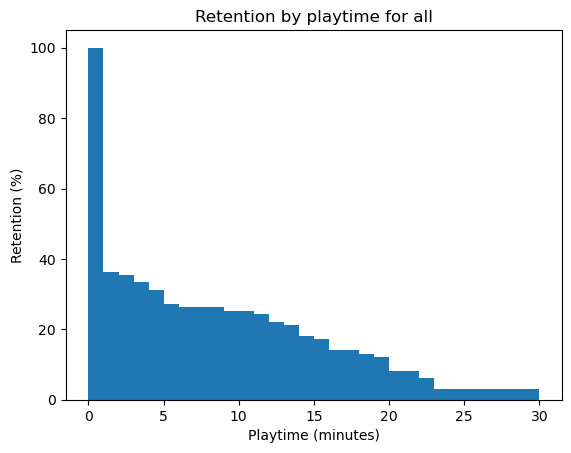

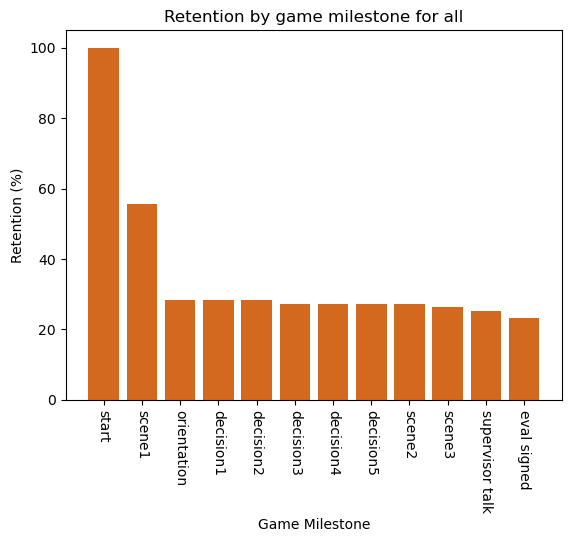

In [162]:
analyze(df, 'all')

Playtime statistic for Entered Scene 1:
count     55.000000
mean      14.585146
std       50.544393
min        0.077100
25%        0.415567
50%        4.595150
75%       15.680008
max      377.799483
Name: playtime, dtype: float64
Retention graph:


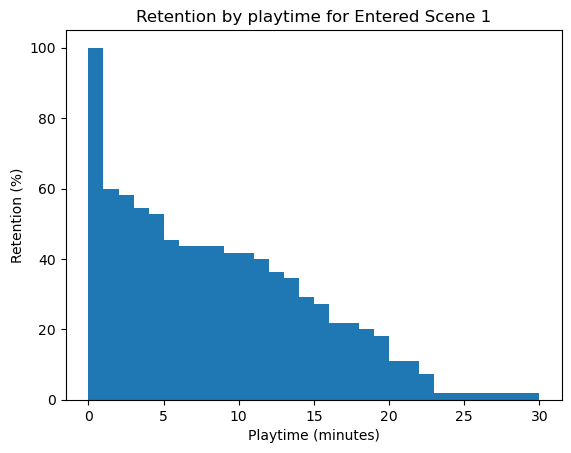

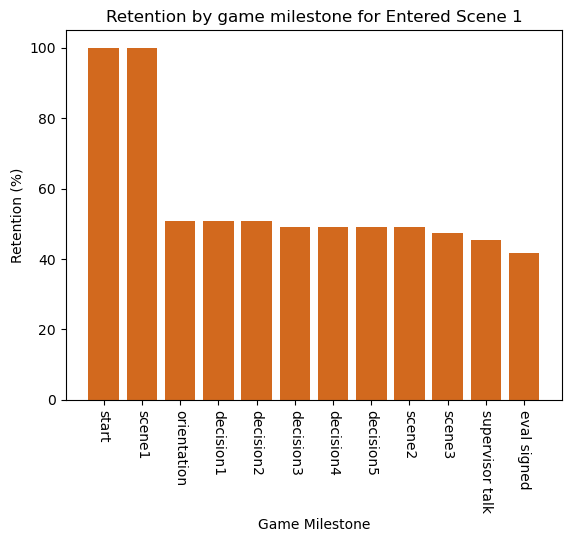

In [163]:
analyze(played, 'Entered Scene 1')

Playtime statistic for Orientation Skipped:
count     22.000000
mean      30.175633
std       77.985174
min        2.808950
25%        5.571467
50%       15.802317
75%       19.806350
max      377.799483
Name: playtime, dtype: float64
Retention graph:


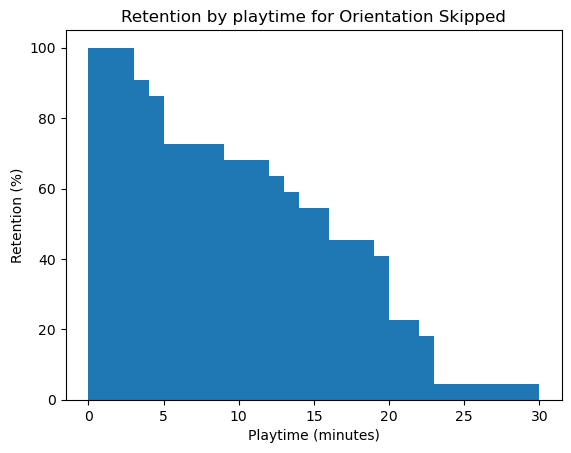

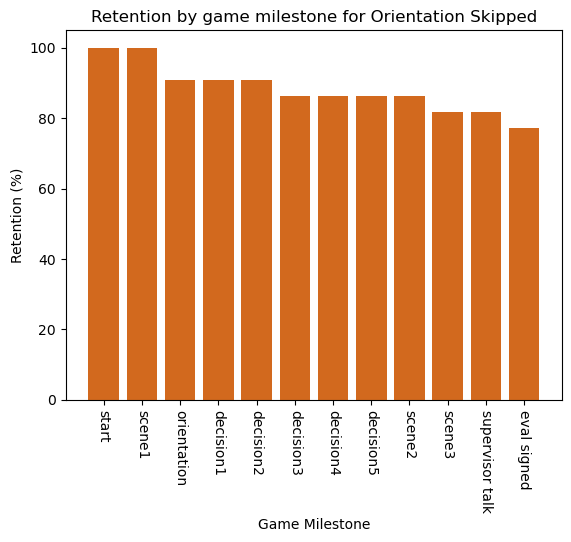

In [164]:
# playthroughs that skipped orientation vs those that didn't
orientation_skipped_ids = played[played['eventType'] == 'orientation_skipped']['sessionId']
orientation_skipped = played[played['sessionId'].isin(orientation_skipped_ids)]
analyze(orientation_skipped, 'Orientation Skipped')


Playtime statistic for Orientation Completed:
count     8.000000
mean     14.858987
std       3.433927
min      10.593400
25%      12.931004
50%      14.111350
75%      16.225283
max      21.249917
Name: playtime, dtype: float64
Retention graph:


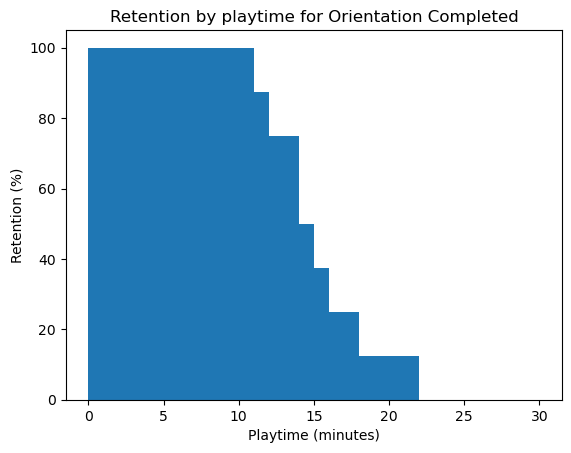

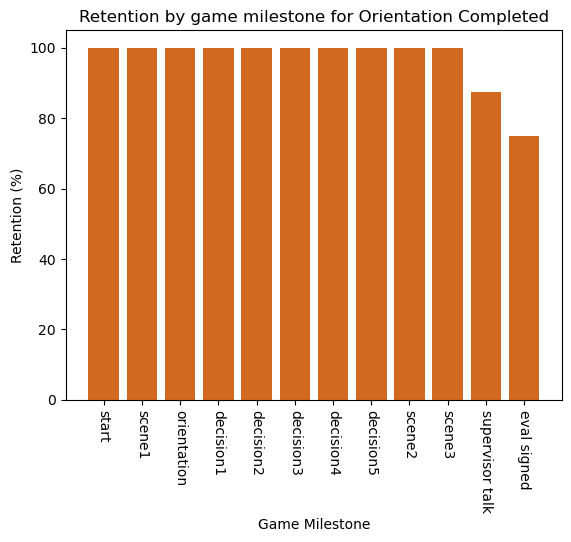

In [166]:
# playthroughs that skipped orientation vs those that didn't
orientation_completed = played[~played['sessionId'].isin(orientation_skipped_ids)]
filtered_ids = orientation_completed[(orientation_completed['eventType'] == 'item_clicked') 
                                     & (orientation_completed['description'] == '1_SReviewFolder (I)')]['sessionId']
orientation_completed = orientation_completed[orientation_completed['sessionId'].isin(filtered_ids)]
analyze(orientation_completed, 'Orientation Completed')


In [190]:
# get average final game stats
# filter to sessions that reached scene 3
scene3 = played[(played['eventType'] == 'scene_entered') & (played['sceneName'] == 'Scene3_Day1_V2')]
# filter out ones that have more than 5 correctToday (bugs)
scene3 = scene3[scene3['gameState_correctToday'] <= 5]

avg_stats = scene3[['gameState_totalCorrect',
        'gameState_totalFlagged',
        'gameState_totalReported',
        'gameState_totalHelped']].mean()

In [191]:
avg_stats.values / [5, 2, 1, 1]

array([0.87692308, 0.25      , 0.11538462, 0.88461538])

In [192]:
scene3[['gameState_totalCorrect',
        'gameState_totalFlagged',
        'gameState_totalReported',
        'gameState_totalHelped']].describe()

,gameState_totalCorrect,gameState_totalFlagged,gameState_totalReported,gameState_totalHelped
count,26.000000,26.000000,26.000000,26.000000
mean,4.384615,0.500000,0.115385,0.884615
std,0.697247,0.761577,0.325813,0.325813
min,3.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,0.000000,1.000000
50%,4.500000,0.000000,0.000000,1.000000
75%,5.000000,1.000000,0.000000,1.000000
max,5.000000,2.000000,1.000000,1.000000


In [ ]:
# concat orientation skipped and completed, to get all that started day
started_day = pd.concat([orientation_skipped, orientation_completed])

30

Playtime statistic for Flagged Bad Behavior:
count     14.000000
mean      41.153407
std       97.146306
min        2.808950
25%       12.853483
50%       17.135475
75%       22.462292
max      377.799483
Name: playtime, dtype: float64
Retention graph:


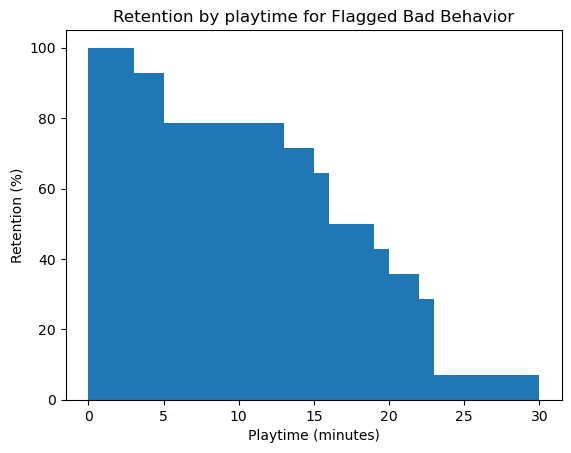

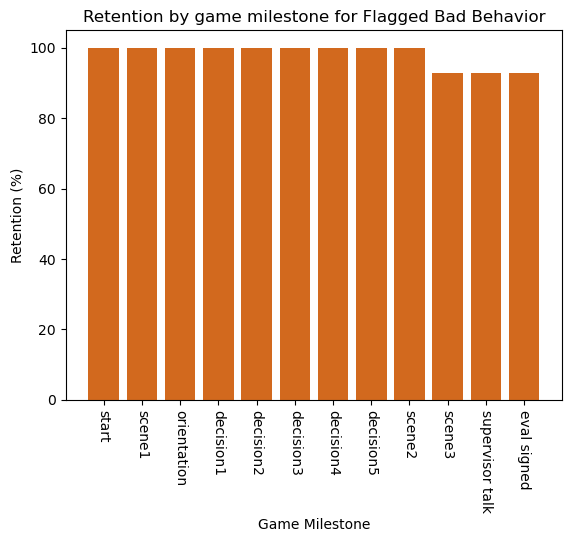

In [184]:
# looks like suspicious events were flagged pretty rarely: analyze on that split
flagged_ids = started_day[started_day['eventType'] == 'bad_behavior_clicked']['sessionId']
flagged = started_day[started_day['sessionId'].isin(flagged_ids)]
analyze(flagged, 'Flagged Bad Behavior')

Playtime statistic for Bad Behavior Not Flagged:
count    16.000000
mean     12.911758
std       5.959260
min       2.919450
25%       9.980179
50%      13.209967
75%      18.391254
max      21.249917
Name: playtime, dtype: float64
Retention graph:


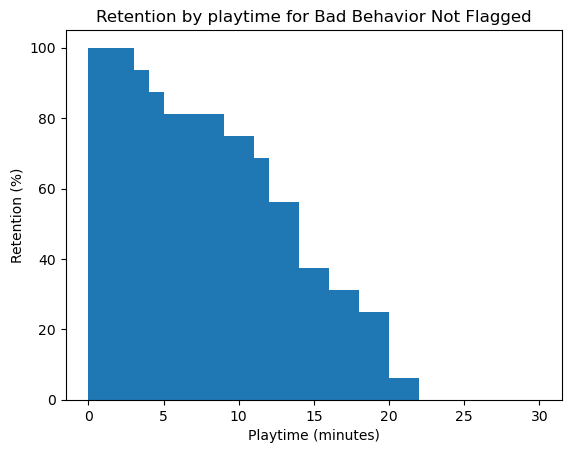

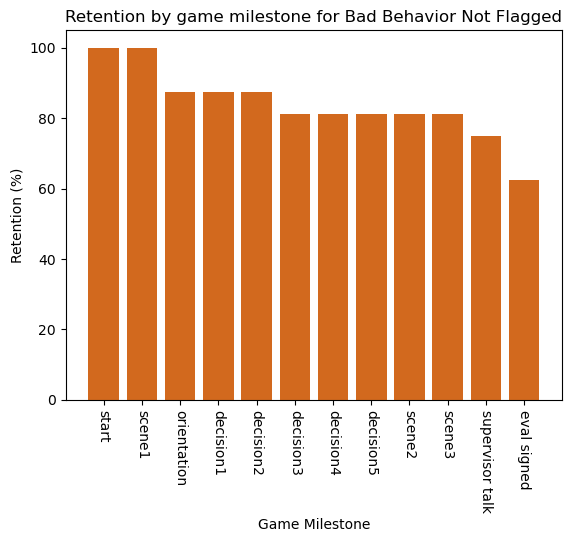

In [185]:
no_flagged = started_day[~started_day['sessionId'].isin(flagged_ids)]
analyze(no_flagged, 'Bad Behavior Not Flagged')